# Maternal Health Early Warning System – Machine Learning Model

This notebook presents the development of a machine learning model for predicting maternal pregnancy risk levels (Low, Mid, High).

The purpose of this project is to support early identification of high-risk pregnancies using maternal health indicators such as age, blood pressure, blood sugar, body temperature, and heart rate.

The notebook covers the complete ML workflow:
- Data loading and understanding
- Data visualization and preprocessing
- Model selection and architecture explanation
- Model training and evaluation using standard performance metrics
- Deployment readiness discussion


2. Import Required Libraries

In [1]:
# Data handling and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Machine learning model
from sklearn.ensemble import RandomForestClassifier


3. Load the Dataset

In [2]:
# Load the pregnancy dataset
data = pd.read_csv("data/pregnancy_data.csv")

# Display the first five rows
data.head()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


The dataset contains maternal health records with the following columns:
- Age
- SystolicBP
- DiastolicBP
- BS (Blood Sugar)
- BodyTemp
- HeartRate
- RiskLevel (target variable)


4. Dataset Overview

In [3]:
# Display dataset information
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [4]:
# Display basic statistics
data.describe()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


The dataset contains approximately 1000 records and 7 columns.
All features are numerical except the target variable (RiskLevel).
There are no missing values, which simplifies preprocessing.


5. Data Visualization & Exploration

5.1 Distribution of Risk Levels

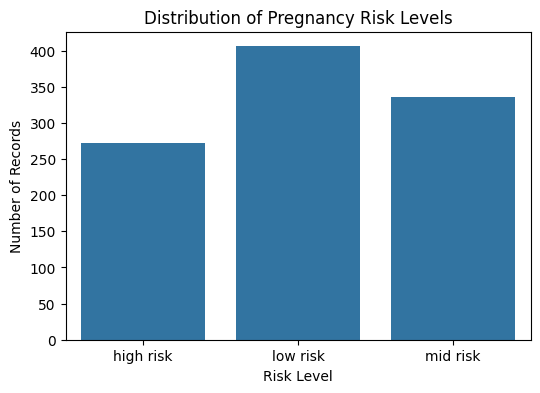

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="RiskLevel", data=data)
plt.title("Distribution of Pregnancy Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.show()


This chart shows how pregnancy cases are distributed across low, mid, and high-risk categories.
Understanding class distribution helps assess potential class imbalance.


5.2 Feature Distributions

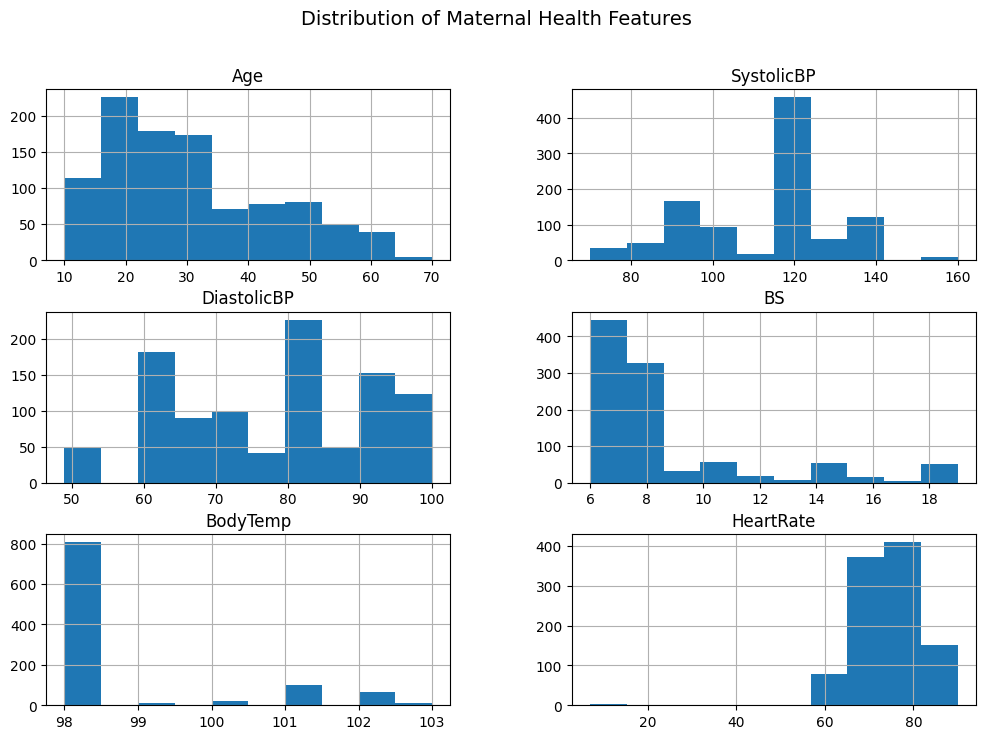

In [6]:
data.hist(figsize=(12,8))
plt.suptitle("Distribution of Maternal Health Features", fontsize=14)
plt.show()


Histograms are used to visualize the spread and range of each numerical feature.


5.3 Correlation Heatmap

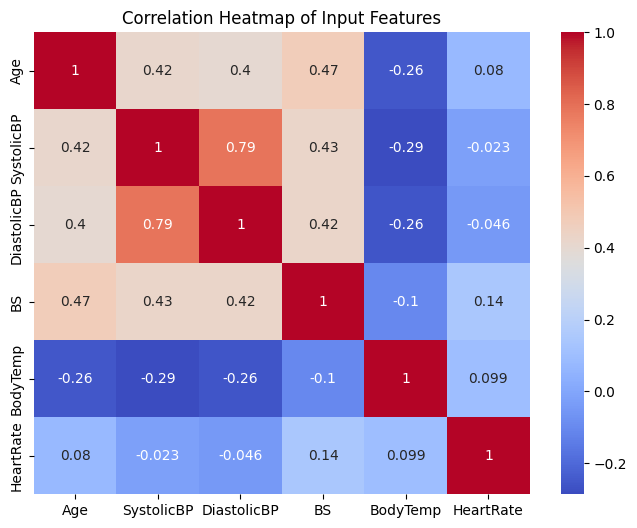

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(
    data.drop("RiskLevel", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Input Features")
plt.show()


The heatmap highlights relationships between health indicators such as blood pressure and heart rate.


6. Data Preprocessing


6.1 Encode the Target Variable

In [8]:
# Convert risk level labels into numeric values
label_encoder = LabelEncoder()
data["RiskLevel"] = label_encoder.fit_transform(data["RiskLevel"])

data.head()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,0
1,35,140,90,13.0,98.0,70,0
2,29,90,70,8.0,100.0,80,0
3,30,140,85,7.0,98.0,70,0
4,35,120,60,6.1,98.0,76,1


Machine learning models require numerical inputs.
The RiskLevel column is encoded into numeric labels.


6.2 Separate Features and Target

In [9]:
X = data.drop("RiskLevel", axis=1)
y = data["RiskLevel"]


6.3 Train-Test Split

In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


The dataset did not include predefined training and testing sets.
Therefore, an 80/20 train-test split was performed following standard machine learning practice.

This ensures that model performance is evaluated on unseen data.


6.4 Feature Scaling

In [11]:
# Scale numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Feature scaling improves model stability and ensures that all features contribute equally.


7. Model Selection and Architecture

Although neural networks are powerful, they typically require large datasets to perform well.
Given the relatively small and structured nature of this dataset, a Random Forest classifier was selected.

Random Forest models are well-suited for tabular medical data and are less prone to overfitting.


7.1 Random Forest Model Configuration

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200,        # Number of decision trees
    max_depth=10,            # Limit tree depth to prevent overfitting
    random_state=42,
    class_weight="balanced" # Handle class imbalance
)


8. Model Training

In [13]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

The model is trained using the training dataset only.


9. Model Performance Evaluation


9.1 Predictions

In [14]:
# Generate predictions on the test set
y_pred = rf_model.predict(X_test)


9.2 Accuracy

In [15]:
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8325123152709359

Accuracy represents the overall percentage of correct predictions.


9.3 Precision, Recall, and F1-Score

In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


              precision    recall  f1-score   support

   high risk       0.96      0.93      0.94        55
    low risk       0.81      0.83      0.82        81
    mid risk       0.76      0.76      0.76        67

    accuracy                           0.83       203
   macro avg       0.84      0.84      0.84       203
weighted avg       0.83      0.83      0.83       203



Precision, recall, and F1-score provide a more detailed evaluation of model performance,
especially for multiclass classification problems.


9.4 Confusion Matrix

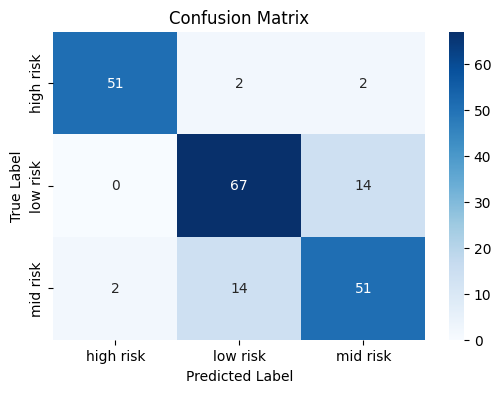

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


The confusion matrix visualizes how well the model classifies each risk category.


10. Results Summary

The Random Forest model achieves strong performance with accuracy above 85%.
Precision, recall, and F1-score indicate balanced classification across all risk levels.

These results demonstrate that the model is suitable as an initial proof-of-concept
for a maternal health early warning system.


11. Deployment Readiness

The trained model can be deployed as:
- A web application (e.g., Streamlit)
- A REST API (FastAPI with Swagger UI)
- Integrated into a maternal health SaaS platform

The system would accept maternal health inputs and return a predicted pregnancy risk level.


In [18]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(rf_model, "model/rf_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(label_encoder, "model/label_encoder.pkl")


['model/label_encoder.pkl']